# HydroMet-ETL: Advanced Hydrometeorological Data Profiling

## DSAI 6226 — Data Engineering and Analytics

**Dataset:** NASA POWER Daily Hydrometeorological Data  
**Study area:** Eight selected locations in Tanzania  
**Temporal coverage:** 2001–2025

### Objective
The initial profiling found no ordinary missing values, duplicate location-date records, invalid dates, basic physical-range violations, or temporal gaps. This notebook therefore performs deeper profiling to identify **data limitations, statistical anomalies, spatial coverage constraints, and engineering risks** without incorrectly treating every extreme observation as an error.

> **Important:** This notebook flags observations and limitations for investigation. It does not automatically delete, replace, or correct observations.


## 1. Import Required Libraries

**Purpose:** Load the libraries needed for tabular analysis, numerical calculations, visualization, and report generation.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Configure Project Paths

**Purpose:** Locate the project root, input dataset, and output directories. The notebook stops with a clear error if the expected interim dataset is missing.


In [2]:
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

DATA_PATH = PROJECT_ROOT / "data" / "interim" / "nasa_power_tanzania_daily.csv"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Run the NASA POWER ingestion pipeline first."
    )


Project root: d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline
Dataset: d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\data\interim\nasa_power_tanzania_daily.csv
Exists: True


## 3. Load and Prepare the Dataset

**Purpose:** Load the interim NASA POWER table, parse dates, verify expected meteorological variables, and derive year, month, and season-related fields for later profiling.


In [3]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

meteo_columns = [
    "T2M", "T2M_MIN", "T2M_MAX", "RH2M",
    "PRECTOTCORR", "WS2M", "ALLSKY_SFC_SW_DWN"
]

missing_columns = [c for c in meteo_columns if c not in df.columns]
if missing_columns:
    raise KeyError(f"Expected columns are missing: {missing_columns}")

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_year"] = df["date"].dt.dayofyear

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Locations: {df['location'].nunique()}")
print(f"Period: {df['date'].min().date()} to {df['date'].max().date()}")
display(df.head())


Rows: 73,048
Columns: 15
Locations: 8
Period: 2001-01-01 to 2025-12-31


,date,location,latitude,longitude,T2M,T2M_MIN,T2M_MAX,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,source,year,month,day_of_year
0,2001-01-01,Arusha,-3.387,36.683,23.610,16.490,31.040,60.620,0.580,0.880,22.340,NASA_POWER,2001,1,1
1,2001-01-02,Arusha,-3.387,36.683,24.040,18.030,30.170,59.560,0.300,1.020,22.210,NASA_POWER,2001,1,2
2,2001-01-03,Arusha,-3.387,36.683,24.870,18.500,31.870,58.280,0.950,1.330,22.780,NASA_POWER,2001,1,3
3,2001-01-04,Arusha,-3.387,36.683,24.770,18.400,31.850,62.470,1.660,1.420,21.990,NASA_POWER,2001,1,4
4,2001-01-05,Arusha,-3.387,36.683,23.070,18.970,28.950,71.450,1.960,1.000,16.190,NASA_POWER,2001,1,5


## 4. Reconfirm the Clean Baseline

**Purpose:** Recheck the core findings from the first notebook so that advanced profiling starts from a documented baseline rather than assuming the data are clean.


In [4]:
baseline = {
    "invalid_dates": int(df["date"].isna().sum()),
    "exact_duplicates": int(df.duplicated().sum()),
    "duplicate_location_date_rows": int(
        df.duplicated(["location", "date"], keep=False).sum()
    ),
    "ordinary_missing_meteo_values": int(df[meteo_columns].isna().sum().sum()),
}
baseline


{'invalid_dates': 0,
 'exact_duplicates': 0,
 'duplicate_location_date_rows': 0,
 'ordinary_missing_meteo_values': 0}

## 5. Assess Spatial Coverage and Representativeness

**Purpose:** Summarize the number and coordinates of sampled points. This does not claim that eight locations are scientifically inadequate by itself; it documents the spatial sampling limitation that must be judged against intended national or regional use.


In [5]:
location_table = (
    df[["location", "latitude", "longitude"]]
    .drop_duplicates()
    .sort_values("location")
    .reset_index(drop=True)
)

display(location_table)

lat_span = location_table["latitude"].max() - location_table["latitude"].min()
lon_span = location_table["longitude"].max() - location_table["longitude"].min()

spatial_summary = {
    "sampled_locations": int(len(location_table)),
    "latitude_min": float(location_table["latitude"].min()),
    "latitude_max": float(location_table["latitude"].max()),
    "longitude_min": float(location_table["longitude"].min()),
    "longitude_max": float(location_table["longitude"].max()),
    "latitude_span_degrees": float(lat_span),
    "longitude_span_degrees": float(lon_span),
}

spatial_summary


,location,latitude,longitude
0,Arusha,-3.387,36.683
1,Dar_es_Salaam,-6.792,39.208
2,Dodoma,-6.163,35.752
3,Mbeya,-8.909,33.461
4,Morogoro,-6.824,37.668
5,Mwanza,-2.516,32.917
6,Songea,-10.682,35.651
7,Tabora,-5.016,32.827


{'sampled_locations': 8,
 'latitude_min': -10.6822,
 'latitude_max': -2.5164,
 'longitude_min': 32.8266,
 'longitude_max': 39.2083,
 'latitude_span_degrees': 8.1658,
 'longitude_span_degrees': 6.381700000000002}

## 6. Visualize the Sampled Locations

**Purpose:** Plot the configured points in longitude-latitude space to make the sparse point-sampling design visually explicit. This is not a national boundary map.


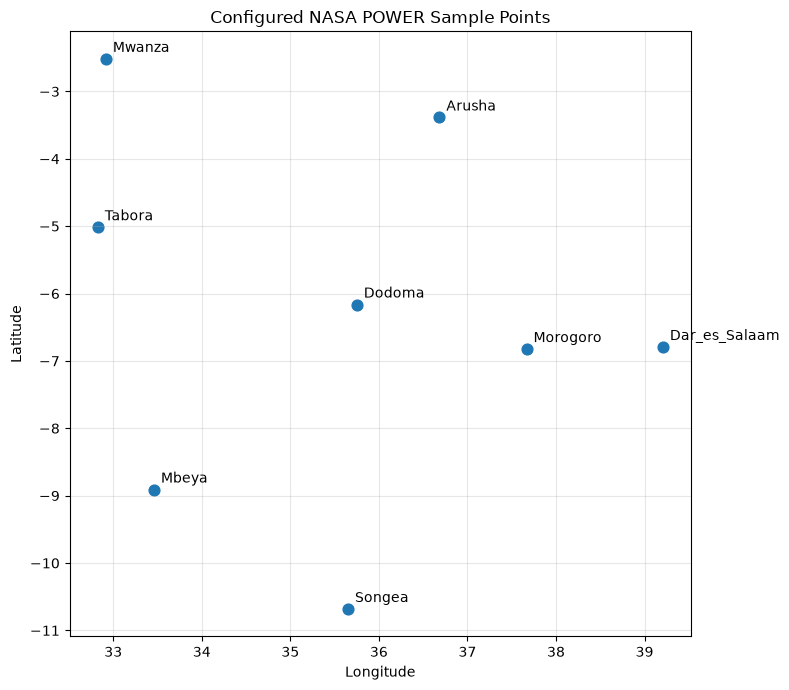

In [6]:
plt.figure(figsize=(8, 7))
plt.scatter(location_table["longitude"], location_table["latitude"], s=60)

for _, row in location_table.iterrows():
    plt.annotate(
        row["location"],
        (row["longitude"], row["latitude"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Configured NASA POWER Sample Points")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "configured_sample_points.png", dpi=200)
plt.show()


## 7. Calculate Variable Percentiles and Extreme Tails

**Purpose:** Calculate robust percentiles for each meteorological variable. Percentiles help describe extreme tails without automatically labeling them as erroneous.


In [7]:
percentiles = df[meteo_columns].quantile(
    [0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
).T

percentiles.columns = [
    "p0_1", "p1", "p5", "p50", "p95", "p99", "p99_9"
]
display(percentiles)


,p0_1,p1,p5,p50,p95,p99,p99_9
T2M,11.191,13.000,16.220,22.690,27.450,28.430,29.120
T2M_MIN,4.571,6.880,10.440,17.820,25.740,26.795,27.420
T2M_MAX,18.310,20.180,22.310,28.240,33.640,35.140,36.330
RH2M,31.672,38.980,46.650,72.910,88.700,91.460,94.000
PRECTOTCORR,0.000,0.000,0.000,0.500,14.710,34.606,89.324
WS2M,0.310,0.440,0.660,2.510,4.870,5.740,6.710
ALLSKY_SFC_SW_DWN,5.080,8.540,12.360,21.110,26.600,27.940,28.890


## 8. Identify IQR-Based Statistical Outliers

**Purpose:** Flag observations outside 1.5 times the interquartile range. These are statistical outliers only and must not be interpreted automatically as bad meteorological data.


In [8]:
def iqr_profile(series):
    x = series.dropna()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (x < lower) | (x > upper)
    return {
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(iqr),
        "lower_bound": float(lower),
        "upper_bound": float(upper),
        "outlier_count": int(mask.sum()),
        "outlier_percent": float(mask.mean() * 100),
    }

iqr_results = {col: iqr_profile(df[col]) for col in meteo_columns}
iqr_table = pd.DataFrame(iqr_results).T
display(iqr_table)


,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
T2M,20.550,24.830,4.280,14.130,31.250,"1,636.000",2.240
T2M_MIN,15.010,20.080,5.070,7.405,27.685,"1,037.000",1.420
T2M_MAX,25.940,30.310,4.370,19.385,36.865,344.000,0.471
RH2M,61.930,81.370,19.440,32.770,110.530,109.000,0.149
PRECTOTCORR,0.030,3.230,3.200,-4.770,8.030,"8,350.000",11.431
WS2M,1.590,3.530,1.940,-1.320,6.440,156.000,0.214
ALLSKY_SFC_SW_DWN,17.770,23.620,5.850,8.995,32.395,897.000,1.228


## 9. Examine Extreme Precipitation Events

**Purpose:** Inspect the highest precipitation observations and calculate high precipitation percentiles. Heavy rainfall is naturally skewed, so these values are candidates for investigation rather than automatic errors.


In [9]:
precip_percentiles = df["PRECTOTCORR"].quantile([0.90, 0.95, 0.99, 0.995, 0.999])
display(precip_percentiles.to_frame("PRECTOTCORR"))

top_rainfall = df.nlargest(
    20, "PRECTOTCORR"
)[["date", "location", "PRECTOTCORR", "RH2M", "T2M"]]

display(top_rainfall)


,PRECTOTCORR
0.900,8.980
0.950,14.710
0.990,34.606
0.995,46.984
0.999,89.324


,date,location,PRECTOTCORR,RH2M,T2M
61846,2020-05-01,Songea,269.770,91.550,21.170
61847,2020-05-02,Songea,249.240,91.640,21.150
63525,2024-12-05,Songea,248.030,88.570,22.440
7263,2020-11-20,Arusha,245.090,86.470,21.770
63244,2024-02-28,Songea,232.290,89.210,22.490
62554,2022-04-09,Songea,226.950,90.060,21.310
62103,2021-01-13,Songea,208.700,91.870,22.060
8341,2023-11-03,Arusha,189.940,89.230,20.140
62055,2020-11-26,Songea,181.800,88.500,23.140
17867,2024-12-02,Dodoma,181.220,88.180,21.570


## 10. Examine Temperature Extremes by Location

**Purpose:** Compare minimum and maximum temperature ranges among locations to determine whether extreme values are concentrated geographically.


In [10]:
temperature_extremes = df.groupby("location").agg(
    mean_temp=("T2M", "mean"),
    minimum_tmin=("T2M_MIN", "min"),
    maximum_tmax=("T2M_MAX", "max"),
    t2m_p01=("T2M", lambda x: x.quantile(0.01)),
    t2m_p99=("T2M", lambda x: x.quantile(0.99)),
)
display(temperature_extremes)


,mean_temp,minimum_tmin,maximum_tmax,t2m_p01,t2m_p99
location,,,,,
Arusha,21.683,7.850,38.170,17.163,26.387
Dar_es_Salaam,26.737,20.030,33.930,24.173,29.047
Dodoma,22.781,8.730,37.050,18.453,27.310
Mbeya,16.490,1.800,31.020,11.373,20.127
Morogoro,23.648,10.470,37.800,18.753,27.520
Mwanza,23.866,12.850,34.420,20.793,27.297
Songea,21.408,7.170,37.460,15.343,27.497
Tabora,22.511,8.400,36.530,17.750,27.284


## 11. Detect Large Day-to-Day Temperature Changes

**Purpose:** Calculate absolute changes in mean temperature between consecutive observations at each location. Large changes are diagnostic flags that may be meteorologically valid.


In [11]:
df = df.sort_values(["location", "date"]).copy()
df["T2M_daily_change"] = df.groupby("location")["T2M"].diff()
df["T2M_abs_daily_change"] = df["T2M_daily_change"].abs()

temp_jump_threshold = df["T2M_abs_daily_change"].quantile(0.999)
large_temp_jumps = df[
    df["T2M_abs_daily_change"] >= temp_jump_threshold
][["date", "location", "T2M", "T2M_daily_change"]]

print(f"99.9th percentile absolute daily temperature change: {temp_jump_threshold:.3f}")
display(large_temp_jumps.head(30))


99.9th percentile absolute daily temperature change: 3.270


,date,location,T2M,T2M_daily_change
1161,2004-03-07,Arusha,22.940,-3.370
2595,2008-02-09,Arusha,24.850,3.400
4073,2012-02-26,Arusha,21.860,-3.330
5158,2015-02-15,Arusha,21.470,-4.170
8112,2023-03-19,Arusha,20.900,-3.310
10589,2004-12-29,Dodoma,20.910,-3.330
11012,2006-02-25,Dodoma,24.350,-3.480
11664,2007-12-09,Dodoma,20.820,-3.540
12083,2009-01-31,Dodoma,20.060,-3.760
12363,2009-11-07,Dodoma,22.440,-3.500


## 12. Detect Large Day-to-Day Precipitation Changes

**Purpose:** Calculate daily precipitation changes and inspect the largest absolute transitions. Because rainfall is intermittent, large changes are expected and are treated only as flags.


In [12]:
df["PRECIP_daily_change"] = df.groupby("location")["PRECTOTCORR"].diff()
df["PRECIP_abs_daily_change"] = df["PRECIP_daily_change"].abs()

precip_jump_threshold = df["PRECIP_abs_daily_change"].quantile(0.999)
large_precip_jumps = df[
    df["PRECIP_abs_daily_change"] >= precip_jump_threshold
][["date", "location", "PRECTOTCORR", "PRECIP_daily_change"]]

print(f"99.9th percentile absolute daily precipitation change: {precip_jump_threshold:.3f}")
display(large_precip_jumps.head(30))


99.9th percentile absolute daily precipitation change: 90.579


,date,location,PRECTOTCORR,PRECIP_daily_change
7260,2020-11-17,Arusha,134.090,122.150
7263,2020-11-20,Arusha,245.090,166.940
7264,2020-11-21,Arusha,51.850,-193.240
8255,2023-08-09,Arusha,16.110,-93.720
8341,2023-11-03,Arusha,189.940,147.490
8342,2023-11-04,Arusha,40.010,-149.930
8878,2025-04-23,Arusha,95.550,91.360
8879,2025-04-24,Arusha,3.950,-91.600
26683,2024-01-22,Dar_es_Salaam,8.590,-91.960
26966,2024-10-31,Dar_es_Salaam,93.890,90.610


## 13. Build Monthly Climatology

**Purpose:** Aggregate variables by calendar month to inspect expected seasonal structure and reveal suspiciously flat or irregular monthly patterns.


,T2M,T2M_MIN,T2M_MAX,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN
month,,,,,,,
1,22.965,19.250,27.430,77.374,6.328,1.868,20.365
2,23.154,19.199,27.897,76.867,5.347,1.833,21.417
3,23.002,19.241,27.687,78.847,5.721,1.842,20.945
4,22.277,18.589,27.058,80.912,5.371,2.342,18.953
5,21.274,16.990,26.712,77.381,2.166,2.687,18.429
6,20.144,15.175,26.322,71.326,0.521,2.832,18.526
7,19.952,14.548,26.542,66.160,0.472,3.066,19.042
8,21.226,15.494,28.029,62.408,0.548,3.218,20.322
9,22.922,16.916,29.906,59.062,0.605,3.392,22.281


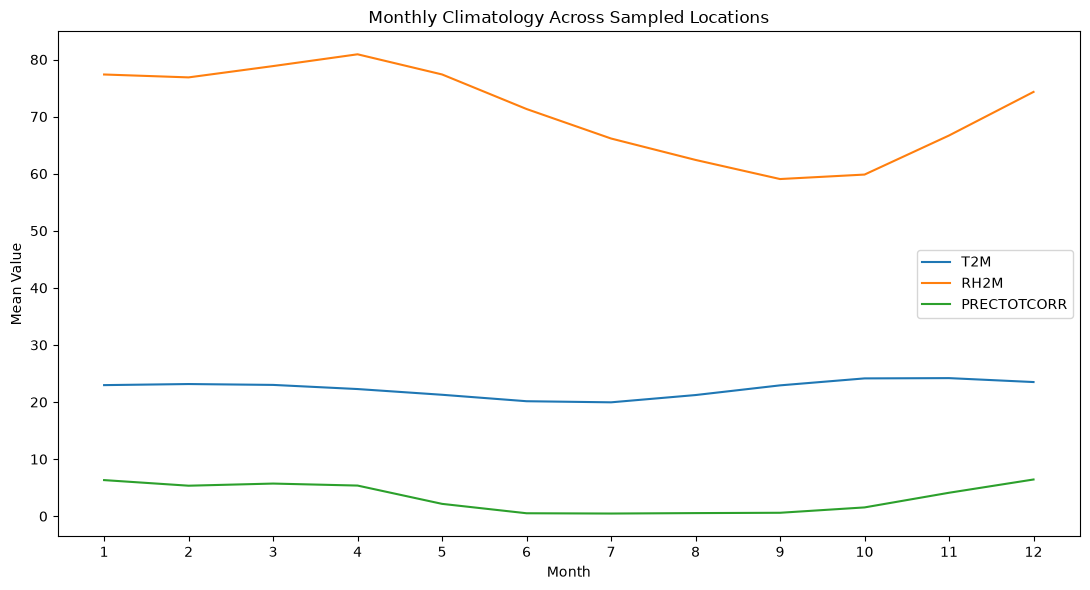

In [13]:
monthly_climatology = (
    df.groupby("month")[meteo_columns]
    .mean()
    .round(3)
)
display(monthly_climatology)

monthly_climatology[["T2M", "RH2M", "PRECTOTCORR"]].plot(
    figsize=(11, 6)
)
plt.title("Monthly Climatology Across Sampled Locations")
plt.xlabel("Month")
plt.ylabel("Mean Value")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "monthly_climatology.png", dpi=200)
plt.show()


## 14. Compare Monthly Rainfall Patterns Across Locations

**Purpose:** Compare monthly mean precipitation among locations to expose spatial differences that would be hidden by a single national average.


location,Arusha,Dar_es_Salaam,Dodoma,Mbeya,Morogoro,Mwanza,Songea,Tabora
month,,,,,,,,
1,3.073,3.493,6.228,11.124,6.341,3.229,11.120,6.014
2,2.929,2.815,4.220,9.606,4.844,2.889,10.336,5.134
3,3.443,5.112,3.944,9.402,6.131,4.667,8.358,4.708
4,5.311,8.515,2.593,5.433,6.419,5.088,5.816,3.796
5,3.024,4.731,0.507,1.300,2.961,2.236,1.461,1.108
6,0.918,0.991,0.092,0.409,0.681,0.523,0.453,0.104
7,1.078,0.452,0.040,0.474,0.439,0.343,0.897,0.053
8,1.199,0.442,0.025,0.371,0.443,1.259,0.434,0.211
9,0.863,0.725,0.022,0.094,0.517,2.144,0.076,0.398


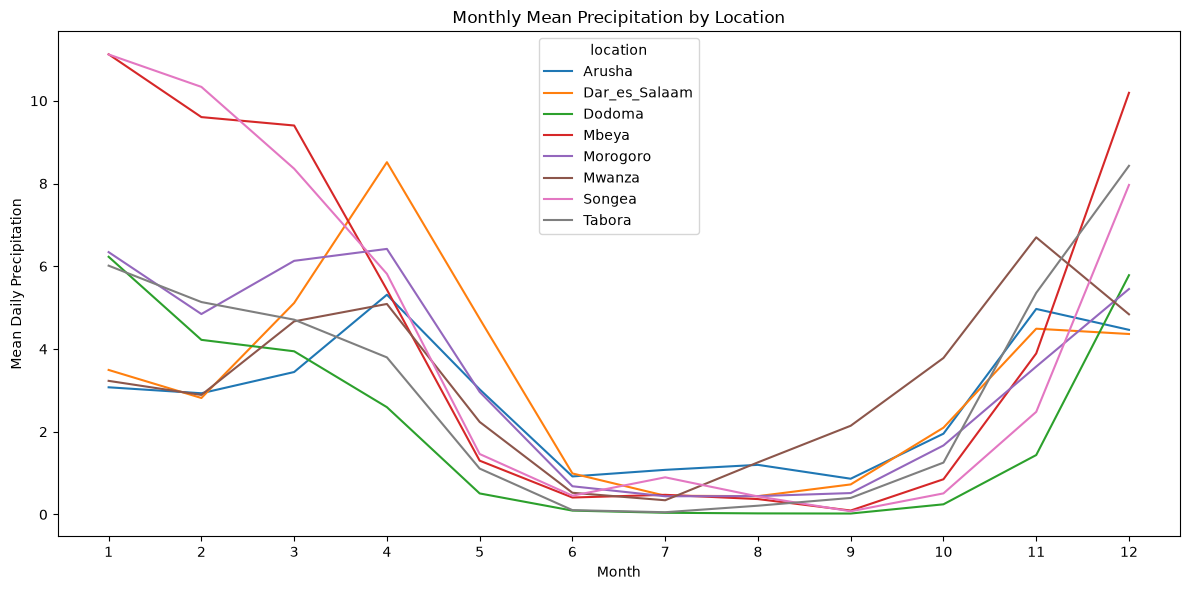

In [14]:
monthly_rain_by_location = (
    df.groupby(["month", "location"])["PRECTOTCORR"]
    .mean()
    .unstack("location")
)

display(monthly_rain_by_location)

monthly_rain_by_location.plot(figsize=(12, 6))
plt.title("Monthly Mean Precipitation by Location")
plt.xlabel("Month")
plt.ylabel("Mean Daily Precipitation")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig(FIGURE_DIR / "monthly_precipitation_by_location.png", dpi=200)
plt.show()


## 15. Assess Inter-Location Variability

**Purpose:** Compare long-term means and standard deviations by location to quantify how strongly climate conditions vary across the eight sampled points.


In [15]:
location_stats = df.groupby("location")[meteo_columns].agg(["mean", "std", "min", "max"])
display(location_stats)


T2M                     T2M_MIN                     T2M_MAX  \
                mean   std    min    max    mean   std    min    max    mean   
location                                                                       
Arusha        21.683 2.087 15.070 28.370  16.386 1.906  7.850 21.680  28.568   
Dar_es_Salaam 26.737 1.272 22.680 30.050  24.970 1.473 20.030 28.010  29.118   
Dodoma        22.781 2.016 14.550 29.100  16.754 2.156  8.730 23.360  29.820   
Mbeya         16.490 2.123  8.760 21.640  11.449 2.851  1.800 17.040  23.370   
Morogoro      23.648 1.978 16.730 29.080  19.113 2.187 10.470 23.390  29.497   
Mwanza        23.866 1.464 19.160 28.430  19.815 1.583 12.850 24.580  28.056   
Songea        21.408 2.862 12.710 29.750  16.408 3.128  7.170 22.710  27.371   
Tabora        22.511 2.050 15.170 28.780  16.707 1.947  8.400 23.050  28.950   

                                    RH2M                      PRECTOTCORR  \
                std    min    max   mean    std    min    max        mean   
location                                                                    
Arusha        2.857 20.120 38.170 69.851 10.240 28.630 93.790       2.764   
Dar_es_Salaam 1.296 25.410 33.930 76.396  5.125 58.740 91.100       3.183   
Dodoma        2.835 21.150 37.050 64.823 12.025 33.150 93.680       2.090   
Mbeya         2.439 13.190 31.020 79.493  8.146 45.190 96.390       4.411   
Morogoro      2.824 21.800 37.800 75.404 10.500 45.650 95.670       3.283   
Mwanza        2.398 20.330 34.420 63.817 11.368 31.580 88.750       3.138   
Songea        3.492 17.490 37.460 73.545 15.571 32.270 95.240       4.133   
Tabora        2.972 21.020 36.530 63.902 16.302 23.690 94.290       3.038   

                                    WS2M                   ALLSKY_SFC_SW_DWN  \
                 std   min     max  mean   std   min   max              mean   
location                                                                       
Arusha         7.634 0.000 245.090 2.626 1.031 0.490 5.920            20.048   
Dar_es_Salaam  6.455 0.000 122.650 4.203 1.084 1.060 8.400            20.399   
Dodoma         6.343 0.000 181.220 3.168 1.109 0.510 5.890            22.311   
Mbeya          9.092 0.000 157.360 0.803 0.301 0.220 2.330            21.585   
Morogoro       6.584 0.000 134.890 2.010 0.590 0.500 4.160            18.940   
Mwanza         5.879 0.000  98.510 2.870 0.983 0.760 6.930            19.818   
Songea        12.278 0.000 269.770 2.335 0.814 0.490 5.230            18.882   
Tabora         7.079 0.000 163.030 2.865 1.179 0.530 6.420            21.659   

                                  
                std   min    max  
location                          
Arusha        4.391 5.680 28.900  
Dar_es_Salaam 4.335 1.770 27.150  
Dodoma        3.837 4.420 29.440  
Mbeya         3.693 5.950 29.700  
Morogoro      4.132 5.140 28.550  
Mwanza        4.939 2.990 28.800  
Songea        4.208 4.180 29.710  
Tabora        3.698 4.460 29.180

## 16. Examine Cross-Variable Correlations

**Purpose:** Calculate correlations among meteorological variables. Strong relationships are not errors, but they matter for downstream analytics, feature engineering, and interpretation.


,T2M,T2M_MIN,T2M_MAX,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN
T2M,1.000,0.890,0.796,-0.327,-0.037,0.524,0.171
T2M_MIN,0.890,1.000,0.451,0.066,0.121,0.403,-0.065
T2M_MAX,0.796,0.451,1.000,-0.697,-0.239,0.505,0.423
RH2M,-0.327,0.066,-0.697,1.000,0.358,-0.474,-0.418
PRECTOTCORR,-0.037,0.121,-0.239,0.358,1.000,-0.206,-0.258
WS2M,0.524,0.403,0.505,-0.474,-0.206,1.000,0.088
ALLSKY_SFC_SW_DWN,0.171,-0.065,0.423,-0.418,-0.258,0.088,1.000


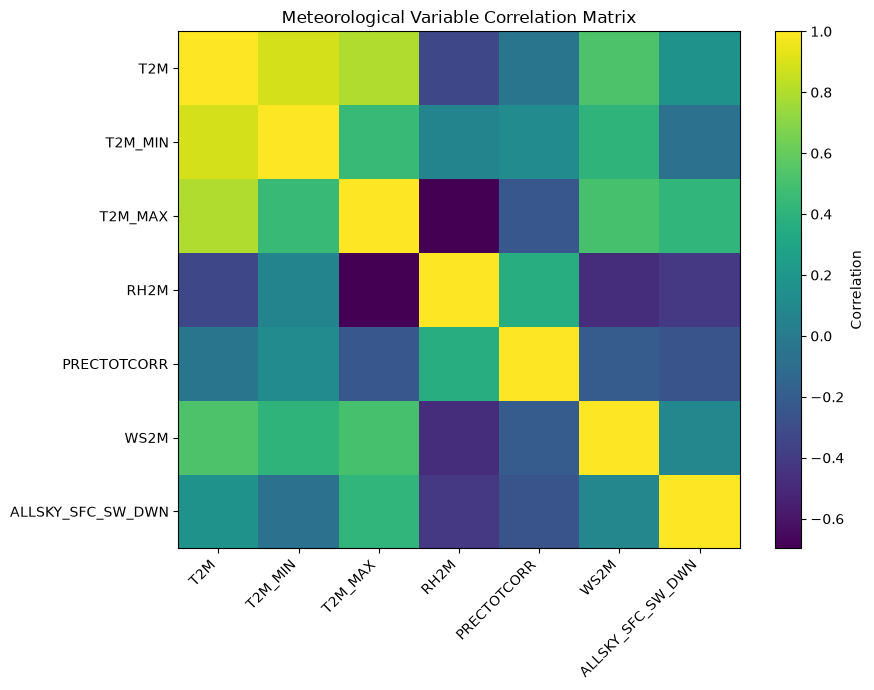

In [16]:
correlation_matrix = df[meteo_columns].corr()
display(correlation_matrix)

plt.figure(figsize=(9, 7))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(meteo_columns)), meteo_columns, rotation=45, ha="right")
plt.yticks(range(len(meteo_columns)), meteo_columns)
plt.title("Meteorological Variable Correlation Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "meteorological_correlations.png", dpi=200)
plt.show()


## 17. Detect Constant or Near-Constant Variables

**Purpose:** Check whether any variable has no variation or extremely low variation. Such fields may provide little analytical value or indicate an ingestion problem.


In [17]:
variance_summary = pd.DataFrame({
    "unique_values": df[meteo_columns].nunique(),
    "variance": df[meteo_columns].var(),
    "std_dev": df[meteo_columns].std(),
})
variance_summary["constant"] = variance_summary["unique_values"] <= 1
display(variance_summary)


,unique_values,variance,std_dev,constant
T2M,1872,11.512,3.393,False
T2M_MIN,2351,17.891,4.230,False
T2M_MAX,1889,11.046,3.323,False
RH2M,5966,169.773,13.030,False
PRECTOTCORR,3522,63.170,7.948,False
WS2M,696,1.701,1.304,False
ALLSKY_SFC_SW_DWN,2403,18.847,4.341,False


## 18. Detect Repeated or Stale Sequences

**Purpose:** Measure the longest consecutive run in which each variable retains exactly the same value within a location. Long runs may be legitimate, especially for zero rainfall, so they are diagnostic rather than automatic failures.


In [18]:
def longest_equal_run(series):
    if series.empty:
        return 0
    groups = series.ne(series.shift()).cumsum()
    return int(series.groupby(groups).size().max())

stale_rows = []
for location, group in df.groupby("location"):
    group = group.sort_values("date")
    for col in meteo_columns:
        stale_rows.append({
            "location": location,
            "variable": col,
            "longest_identical_run_days": longest_equal_run(group[col])
        })

stale_summary = pd.DataFrame(stale_rows).sort_values(
    "longest_identical_run_days", ascending=False
)
display(stale_summary.head(30))


,location,variable,longest_identical_run_days
25,Mbeya,PRECTOTCORR,73
46,Songea,PRECTOTCORR,52
53,Tabora,PRECTOTCORR,52
18,Dodoma,PRECTOTCORR,41
39,Mwanza,PRECTOTCORR,15
32,Morogoro,PRECTOTCORR,14
4,Arusha,PRECTOTCORR,12
11,Dar_es_Salaam,PRECTOTCORR,10
12,Dar_es_Salaam,WS2M,3
26,Mbeya,WS2M,3


## 19. Check Cross-Location Identical Measurements

**Purpose:** Count dates on which all eight locations have exactly the same value for a variable. Repeated identical values across all locations can be useful for detecting unexpected spatial uniformity.


In [19]:
cross_location_uniformity = []

for col in meteo_columns:
    daily_unique = df.groupby("date")[col].nunique(dropna=False)
    identical_days = int((daily_unique == 1).sum())
    cross_location_uniformity.append({
        "variable": col,
        "days_identical_across_all_locations": identical_days,
        "percent_of_dates": float(identical_days / len(daily_unique) * 100)
    })

cross_location_uniformity = pd.DataFrame(cross_location_uniformity)
display(cross_location_uniformity)


,variable,days_identical_across_all_locations,percent_of_dates
0,T2M,0,0.000
1,T2M_MIN,0,0.000
2,T2M_MAX,0,0.000
3,RH2M,0,0.000
4,PRECTOTCORR,11,0.120
5,WS2M,0,0.000
6,ALLSKY_SFC_SW_DWN,0,0.000


## 20. Assess Source Diversity and Lineage

**Purpose:** Document how many source labels exist in the current table. A single-source dataset is not inherently low quality, but it creates a dependency and limits independent cross-source validation.


In [20]:
if "source" in df.columns:
    source_counts = df["source"].value_counts(dropna=False)
else:
    source_counts = pd.Series({"NASA_POWER (inferred from pipeline)": len(df)})

display(source_counts.to_frame("records"))

source_diversity = {
    "number_of_source_labels": int(len(source_counts)),
    "single_source_dependency": bool(len(source_counts) == 1),
}
source_diversity


,records
source,
NASA_POWER,73048


{'number_of_source_labels': 1, 'single_source_dependency': True}

## 21. Quantify Data Coverage Versus Intended Use

**Purpose:** Create an explicit coverage profile. The dataset is temporally dense but spatially consists of only eight configured point locations; this is a dataset-design limitation to document when proposing national-scale uses.


In [21]:
coverage_profile = {
    "records": int(len(df)),
    "years_covered": int(df["year"].nunique()),
    "locations": int(df["location"].nunique()),
    "daily_temporal_resolution": True,
    "nationally_exhaustive_spatial_coverage": False,
    "coverage_note": (
        "The current extract represents eight configured point locations. "
        "It should not be described as exhaustive national spatial coverage."
    )
}
coverage_profile


{'records': 73048,
 'years_covered': 25,
 'locations': 8,
 'daily_temporal_resolution': True,
 'nationally_exhaustive_spatial_coverage': False,
 'coverage_note': 'The current extract represents eight configured point locations. It should not be described as exhaustive national spatial coverage.'}

## 22. Create Advanced Candidate Engineering Problems

**Purpose:** Convert the evidence into defensible engineering limitations. These are deliberately distinguished from false claims about missing values or duplicates.


In [22]:
advanced_problems = pd.DataFrame([
    {
        "dimension": "Spatial coverage",
        "problem": "Limited point-based spatial representation",
        "evidence": f"{df['location'].nunique()} configured locations represent the current Tanzania extract",
        "engineering_implication": (
            "National or district-level applications may require denser grid-based "
            "or administrative-area coverage and scalable spatial ingestion."
        )
    },
    {
        "dimension": "Source resilience / validation",
        "problem": "Single-source dependency",
        "evidence": f"{len(source_counts)} source label(s) are represented in the current pipeline",
        "engineering_implication": (
            "Independent cross-source validation is unavailable; adding CHIRPS or "
            "another trusted source would require harmonization and lineage controls."
        )
    },
    {
        "dimension": "Extreme-value quality assurance",
        "problem": "Statistical extremes require contextual validation",
        "evidence": (
            f"IQR profiling flags {int(iqr_table['outlier_count'].sum())} variable-level "
            "observations across all meteorological variables; flags are not automatically errors"
        ),
        "engineering_implication": (
            "The pipeline needs explicit quality flags and domain-aware validation "
            "rather than automatic deletion of extreme hydrometeorological observations."
        )
    }
])

display(advanced_problems)

advanced_problems.to_csv(
    REPORT_DIR / "advanced_candidate_engineering_problems.csv",
    index=False
)


,dimension,problem,evidence,engineering_implication
0,Spatial coverage,Limited point-based spatial representation,8 configured locations represent the current T...,National or district-level applications may re...
1,Source resilience / validation,Single-source dependency,1 source label(s) are represented in the curre...,Independent cross-source validation is unavail...
2,Extreme-value quality assurance,Statistical extremes require contextual valida...,IQR profiling flags 12529 variable-level obser...,The pipeline needs explicit quality flags and ...


## 23. Build an Advanced Profiling Report

**Purpose:** Save the principal findings in JSON so they can be reused in documentation and later pipeline stages without manually copying notebook results.


In [23]:
advanced_report = {
    "dataset": {
        "rows": int(len(df)),
        "locations": int(df["location"].nunique()),
        "start_date": str(df["date"].min()),
        "end_date": str(df["date"].max()),
    },
    "baseline_quality": baseline,
    "spatial_coverage": spatial_summary,
    "source_diversity": source_diversity,
    "coverage_profile": coverage_profile,
    "iqr_outliers": iqr_results,
    "temperature_daily_change_99_9_percentile": float(temp_jump_threshold),
    "precipitation_daily_change_99_9_percentile": float(precip_jump_threshold),
    "cross_location_uniformity": cross_location_uniformity.to_dict(orient="records"),
    "longest_stale_sequences": stale_summary.head(30).to_dict(orient="records"),
}

ADVANCED_REPORT_PATH = REPORT_DIR / "advanced_data_profiling_report.json"

with open(ADVANCED_REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4)

print("Saved:", ADVANCED_REPORT_PATH)


Saved: d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\outputs\reports\advanced_data_profiling_report.json


## 24. Display the Final Advanced Profiling Summary

**Purpose:** Summarize what the analysis actually supports and list the generated outputs. The conclusion deliberately separates basic data cleanliness from broader dataset limitations.


In [24]:
print("=" * 70)
print("HYDROMET ADVANCED PROFILING SUMMARY")
print("=" * 70)

print(f"Rows: {len(df):,}")
print(f"Locations: {df['location'].nunique()}")
print(f"Period: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Ordinary missing meteorological values: {df[meteo_columns].isna().sum().sum():,}")
print(f"Duplicate location-date rows: {df.duplicated(['location', 'date'], keep=False).sum():,}")
print(f"Total IQR statistical flags: {int(iqr_table['outlier_count'].sum()):,}")
print(f"Source labels represented: {len(source_counts)}")

print("\nInterpretation:")
print("- Basic structural and validity checks remain very strong.")
print("- Statistical extremes are flags for investigation, not automatic errors.")
print("- The current extract has dense temporal coverage but only eight configured points.")
print("- The current pipeline depends on a single hydrometeorological source.")
print("- These limitations create defensible data-engineering opportunities for the project.")

print("\nGenerated outputs:")
print("-", REPORT_DIR / "advanced_candidate_engineering_problems.csv")
print("-", ADVANCED_REPORT_PATH)
print("-", FIGURE_DIR / "configured_sample_points.png")
print("-", FIGURE_DIR / "monthly_climatology.png")
print("-", FIGURE_DIR / "monthly_precipitation_by_location.png")
print("-", FIGURE_DIR / "meteorological_correlations.png")


HYDROMET ADVANCED PROFILING SUMMARY
Rows: 73,048
Locations: 8
Period: 2001-01-01 to 2025-12-31
Ordinary missing meteorological values: 0
Duplicate location-date rows: 0
Total IQR statistical flags: 12,529
Source labels represented: 1

Interpretation:
- Basic structural and validity checks remain very strong.
- Statistical extremes are flags for investigation, not automatic errors.
- The current extract has dense temporal coverage but only eight configured points.
- The current pipeline depends on a single hydrometeorological source.
- These limitations create defensible data-engineering opportunities for the project.

Generated outputs:
- d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\outputs\reports\advanced_candidate_engineering_problems.csv
- d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\outputs\reports\advanced_data_profiling_report.json
- d:\NMAIST_MASTERS LIFE\Semi

## Interpretation Guidance

When reviewing this notebook, use the following terminology carefully:

- **Invalid value:** Violates a clearly defined domain or schema rule.
- **Missing value:** An expected observation or field is absent.
- **Statistical outlier:** Unusual relative to the observed distribution, but potentially valid.
- **Extreme event:** A rare hydrometeorological observation that may be scientifically meaningful.
- **Dataset limitation:** A constraint such as sparse spatial coverage or reliance on one source.
- **Engineering problem:** A limitation that can be addressed through pipeline design, validation, harmonization, storage, orchestration, or governance.

This distinction prevents the project from claiming that valid extreme weather observations are data errors.
